### TO DO
- vectorize tweets for each timeline

- plot them on a chart and compare the tls and see if there has been a shift among timelines

- Use K-means to see if sil score changes in 3 cluster or at all
	

In [ ]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import TruncatedSVD
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality 
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Persian reshaping
import arabic_reshaper
from bidi.algorithm import get_display

def reshape_persian(text):
    if not isinstance(text, str):
        return text
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

# Plot settings
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

print('Done')

Done


In [4]:
# Load the dataset
df = pd.read_csv('../data/preprocessed/all_processed.csv', encoding = 'utf-8-sig')
df.head()

,message_id,cleaned_text,timeline,normalized,tokens,tokens_persian,tokens_stemmed,final_tokens_freq_stemmed,final_tokens_freq_not_stemmed
0,129507,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,timeline_1,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,"['تنها', 'کسی', 'که', 'تو', 'مملکت', 'داره', '...","['تنها', 'کسی', 'که', 'تو', 'مملکت', 'داره', '...","['تنها', 'کسی', 'که', 'تو', 'مملک', 'داره', 'ک...","['مملک', 'انجا', 'چسب', 'زن', 'الویه', 'نامینو...","['مملکت', 'کارش', 'انجام', 'چسب', 'زن', 'الویه..."
1,129512,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,timeline_1,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,"['اولین', 'سالی', 'که', 'بابانوئل', 'برای', 'ب...","['اولین', 'سالی', 'که', 'بابانوئل', 'برای', 'ب...","['اولین', 'سال', 'که', 'بابانوئل', 'برا', 'بچه...","['بابانوئل', 'آورد', 'فکر', 'واکن', 'دختر', 'ص...","['سالی', 'بابانوئل', 'بچه\u200cهای', 'آورد', '..."
2,129513,داشتم گالریمو مرتب می‌کردم عکس بچگی این تخم سگ...,timeline_1,داشتم گالریمو مرتب می‌کردم عکس بچگی این تخم سگ...,"['داشتم', 'گالریمو', 'مرتب', 'می\u200cکردم', '...","['داشتم', 'گالریمو', 'مرتب', 'می\u200cکردم', '...","['داشت', 'گالریمو', 'مرتب', 'می\u200cکردم', 'ع...","['داشت', 'گالریمو', 'مرتب', 'عکس', 'بچگی', 'تخ...","['داشتم', 'گالریمو', 'مرتب', 'عکس', 'بچگی', 'ت..."
3,129514,دم رفتن بهم گفت «اصن حواست بود کجاها امن بودم؟...,timeline_1,دم رفتن بهم گفت اصن حواست بود کجاها امن بودم ک...,"['دم', 'رفتن', 'بهم', 'گفت', 'اصن', 'حواست', '...","['دم', 'رفتن', 'بهم', 'گفت', 'اصن', 'حواست', '...","['دم', 'رفتن', 'بهم', 'گفت', 'اصن', 'حواس', 'ب...","['دم', 'رفتن', 'اصن', 'حواس', 'امن', 'ادب', 'ن...","['دم', 'رفتن', 'اصن', 'حواست', 'کجاها', 'امن',..."
4,129516,تو خیابون ما ۲۰ ساله یه ساندویچی هست، صاحبش خا...,timeline_1,تو خیابون ما ۲۰ ساله یه ساندویچی هست صاحبش خان...,"['تو', 'خیابون', 'ما', '۲۰', 'ساله', 'یه', 'سا...","['تو', 'خیابون', 'ما', '۲۰', 'ساله', 'یه', 'سا...","['تو', 'خیابان', 'ما', '۲۰', 'ساله', 'یک', 'سا...","['خیابان', '۲۰', 'ساله', 'ساندویچ', 'صاحب', 'خ...","['خیابون', '۲۰', 'ساله', 'یه', 'ساندویچی', 'صا..."


In [5]:
# Vectorize 
texts = df['normalized'].fillna('').tolist()

# TF-IDF
tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range = (1, 2),
    analyzer = 'word',
    token_pattern = r'(?u)\b\w+\b'    # Split on word boundaries
)

X_tfidf = tfidf.fit_transform(texts)
X_tfidf.shape

(11174, 5000)

In [6]:
# PCA
pca = PCA(n_components = 2, random_state = 42)
X_2d = pca.fit_transform(X_tfidf.toarray())
print('Done')

Done


In [7]:
# t-SNE
pca50 = PCA(n_components = 50, random_state = 42)
X_dense = pca50.fit_transform(X_tfidf.toarray())
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30, max_iter = 1000, verbose = 1)
X_2d = tsne.fit_transform(X_dense)
print('Done')

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 11174 samples in 0.001s...
[t-SNE] Computed neighbors for 11174 samples in 0.249s...
[t-SNE] Computed conditional probabilities for sample 1000 / 11174
[t-SNE] Computed conditional probabilities for sample 2000 / 11174
[t-SNE] Computed conditional probabilities for sample 3000 / 11174
[t-SNE] Computed conditional probabilities for sample 4000 / 11174
[t-SNE] Computed conditional probabilities for sample 5000 / 11174
[t-SNE] Computed conditional probabilities for sample 6000 / 11174
[t-SNE] Computed conditional probabilities for sample 7000 / 11174
[t-SNE] Computed conditional probabilities for sample 8000 / 11174
[t-SNE] Computed conditional probabilities for sample 9000 / 11174
[t-SNE] Computed conditional probabilities for sample 10000 / 11174
[t-SNE] Computed conditional probabilities for sample 11000 / 11174
[t-SNE] Computed conditional probabilities for sample 11174 / 11174
[t-SNE] Mean sigma: 0.064855
[t-SNE] KL divergence

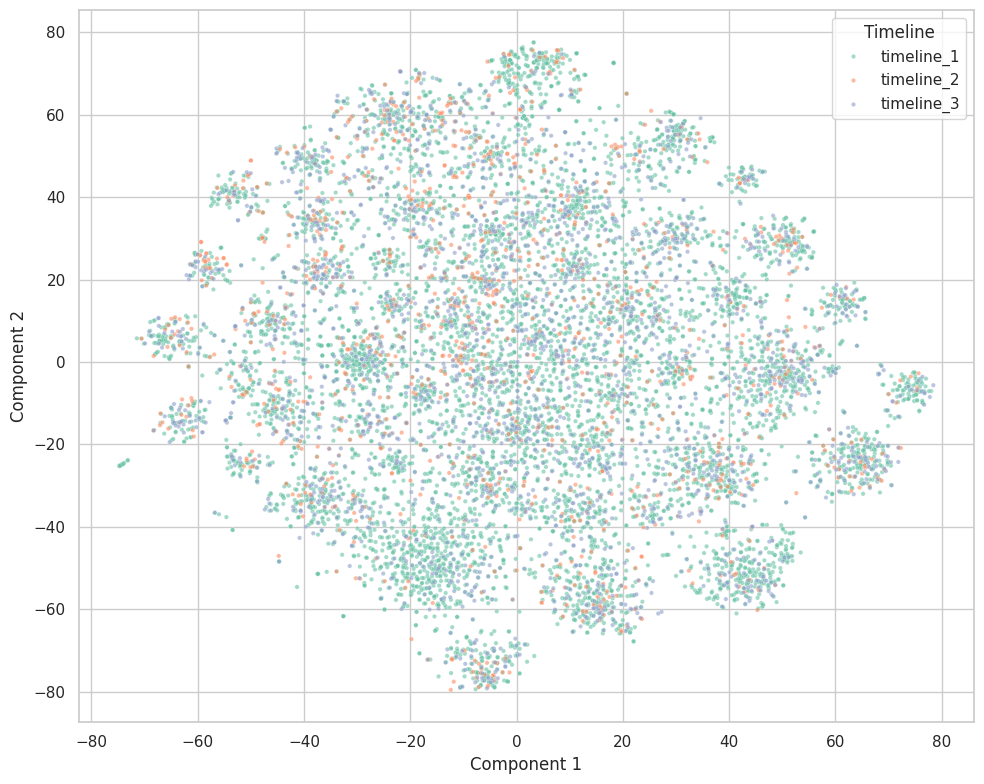

In [8]:
# Plot 
plot_df = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
    'timeline': df['timeline']
})

plt.figure(figsize = (10, 8))

sns.scatterplot(
    data = plot_df,
    x = 'x',
    y = 'y',
    hue = 'timeline',
    palette = 'Set2',
    alpha = 0.6, 
    s = 10
)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title = 'Timeline')
plt.tight_layout()
plt.show()

No clear distinction is visible, we are going to try for 3D

In [15]:
samples_per_timeline = 1000
sample_indices = []

# Stratify sampling
for tl in sorted(df['timeline'].unique()):
    tl_indices = np.where(df['timeline'] == tl)[0]
    n_available = len(tl_indices)
    n_samples = min(samples_per_timeline, n_available)
    chosen = np.random.choice(tl_indices, size = n_samples, replace = False)
    sample_indices.extend(chosen)

# Combine into a single array
sample_idx = np.array(sample_indices)
np.random.shuffle(sample_idx)

# Extract TF-IDF
X_sample = X_tfidf[sample_idx]
df_sample = df.iloc[sample_idx].reset_index(drop = True)

# SVD
svd = TruncatedSVD(n_components = 50, random_state = 42)
X_dense = svd.fit_transform(X_sample)

# t-SNE 3D
tsne = TSNE(n_components = 3, random_state = 42, perplexity = 30, max_iter = 1000, verbose = 1)
X_3d = tsne.fit_transform(X_dense)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.000s...
[t-SNE] Computed neighbors for 3000 samples in 0.117s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 0.100295
[t-SNE] KL divergence after 50 iterations with early exaggeration: 76.315865
[t-SNE] KL divergence after 900 iterations: 2.134140


In [17]:
# Plot 3D
plotly_df = pd.DataFrame({
    'x': X_3d[:, 0],
    'y': X_3d[:, 1],
    'z': X_3d[:, 2],
    'timeline': df_sample['timeline']
})

fig = px.scatter_3d(
    plotly_df,
    x = 'x', y = 'y', z = 'z',
    color = 'timeline',
    opacity = 0.6,
    size_max = 3,
    title = '3D t-SNE'
)

fig.update_traces(marker = dict(size = 3))
fig.show()

As shown above, also there is no visible distinction in stratified sampled t-SNE.

In [ ]:
# K-means clustering
sample_size = min(3000, X_tfidf.shape[0])
indices = np.random.choice(X_tfidf.shape[0], sample_size, replace = False)
X_sample = X_tfidf[indices]

for k in [3, 4, 5, 6, 7]:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels)
    print(f'k = {k}, sil = {sil:.3f}')

k = 3, sil = 0.002
k = 4, sil = 0.002
k = 5, sil = 0.002
k = 6, sil = 0.003
k = 7, sil = 0.003


As shown above, the scores among clusters are effectively zero, showing extreme overlap among clusters.